# Step 3 — Perturbation GSEA (LINCS-style filtered panel, robust version)

This notebook builds **pathway signatures for a curated perturbation panel** using
a filtered long-format signature table and a matching perturbation manifest.

It is designed to work directly with the outputs from:

- `build_ranked_perturbation_signatures_helper.ipynb`

## Required inputs

- `data/external/lincs/lincs_filtered_signatures.tsv`
- `data/external/lincs/perturbation_manifest.tsv`
- `results/tables/GSE235236_UC_vs_HC_disease_pathway_signature.tsv`

## What is improved in this version

Some perturbations may have too few overlapping genes with the pathway library.
Instead of crashing the whole notebook, this version:

- checks overlap before running GSEA
- skips perturbations that cannot support the chosen `min_size`
- records the reason in a summary table
- continues with the remaining perturbations

## Main outputs

- one GSEA result table per successful perturbation
- combined perturbation pathway signatures (long)
- perturbation-by-pathway NES matrix (wide)
- disease–perturbation pathway alignment table
- preview candidate reversal ranking
- a run summary including skipped perturbations


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gseapy as gp


## 1. Define paths


In [2]:
PROJECT_DIR = Path("..")
LINCS_DIR = PROJECT_DIR / "data" / "external" / "lincs"
RESULTS_TABLES = PROJECT_DIR / "results" / "tables"
RESULTS_FIGURES = PROJECT_DIR / "results" / "figures"

RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)

LINCS_SIGNATURE_FILE = LINCS_DIR / "lincs_filtered_signatures.tsv"
PERT_MANIFEST_FILE = LINCS_DIR / "perturbation_manifest.tsv"
DISEASE_SIGNATURE_FILE = RESULTS_TABLES / "GSE235236_UC_vs_HC_disease_pathway_signature.tsv"

print("LINCS signature file:", LINCS_SIGNATURE_FILE)
print("Exists:", LINCS_SIGNATURE_FILE.exists())
print("Perturbation manifest:", PERT_MANIFEST_FILE)
print("Exists:", PERT_MANIFEST_FILE.exists())
print("Disease pathway signature:", DISEASE_SIGNATURE_FILE)
print("Exists:", DISEASE_SIGNATURE_FILE.exists())


LINCS signature file: ../data/external/lincs/lincs_filtered_signatures.tsv
Exists: True
Perturbation manifest: ../data/external/lincs/perturbation_manifest.tsv
Exists: True
Disease pathway signature: ../results/tables/GSE235236_UC_vs_HC_disease_pathway_signature.tsv
Exists: True


## 2. Load required inputs


In [3]:
if not LINCS_SIGNATURE_FILE.exists():
    raise FileNotFoundError(
        f"Missing file: {LINCS_SIGNATURE_FILE}\n"
        "Create it first using the helper notebook."
    )

if not PERT_MANIFEST_FILE.exists():
    raise FileNotFoundError(
        f"Missing file: {PERT_MANIFEST_FILE}\n"
        "Create it first using the helper notebook."
    )

if not DISEASE_SIGNATURE_FILE.exists():
    raise FileNotFoundError(
        f"Missing file: {DISEASE_SIGNATURE_FILE}\n"
        "Run Step 2 first so the disease pathway signature is available."
    )

lincs_sig = pd.read_csv(LINCS_SIGNATURE_FILE, sep="\t")
pert_manifest = pd.read_csv(PERT_MANIFEST_FILE, sep="\t")
disease_sig = pd.read_csv(DISEASE_SIGNATURE_FILE, sep="\t")

print("LINCS signatures shape:", lincs_sig.shape)
print("Manifest shape:", pert_manifest.shape)
print("Disease signature shape:", disease_sig.shape)


LINCS signatures shape: (351, 3)
Manifest shape: (4, 6)
Disease signature shape: (50, 3)


In [4]:
lincs_sig.head()


,perturbation_id,gene_symbol,rank_score
0,drug_001,FKBP5,50
1,drug_001,TSC22D3,49
2,drug_001,DUSP1,48
3,drug_001,DUSP4,47
4,drug_001,DUSP5,46


In [5]:
pert_manifest.head()


,perturbation_id,perturbation_name,cell_line,dose,time_h,signature_source
0,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature
1,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature
2,drug_004,tofacitinib,NaN,NaN,NaN,curated_public_signature
3,drug_005,ruxolitinib,NaN,NaN,NaN,curated_public_signature


In [6]:
disease_sig.head()


,Pathway,NES,FDR
0,1,2.018700,0.000000
1,2,1.789889,0.003271
2,3,1.773973,0.002181
3,6,1.747378,0.002617
4,12,1.570056,0.015439


## 3. Validate required columns


In [7]:
required_sig_cols = {"perturbation_id", "gene_symbol", "rank_score"}
required_manifest_cols = {"perturbation_id", "perturbation_name", "cell_line", "dose", "time_h", "signature_source"}
required_disease_cols = {"Pathway", "NES", "FDR"}

missing_sig = required_sig_cols - set(lincs_sig.columns)
missing_manifest = required_manifest_cols - set(pert_manifest.columns)
missing_disease = required_disease_cols - set(disease_sig.columns)

if missing_sig:
    raise ValueError(f"Missing required LINCS signature columns: {sorted(missing_sig)}")
if missing_manifest:
    raise ValueError(f"Missing required manifest columns: {sorted(missing_manifest)}")
if missing_disease:
    raise ValueError(f"Missing required disease signature columns: {sorted(missing_disease)}")

print("All required columns are present.")


All required columns are present.


## 4. Basic cleanup


In [8]:
lincs_sig = lincs_sig.copy()
pert_manifest = pert_manifest.copy()
disease_sig = disease_sig.copy()

lincs_sig["perturbation_id"] = lincs_sig["perturbation_id"].astype(str)
lincs_sig["gene_symbol"] = lincs_sig["gene_symbol"].astype(str).str.upper().str.strip()
lincs_sig["rank_score"] = pd.to_numeric(lincs_sig["rank_score"], errors="coerce")
lincs_sig = lincs_sig.dropna(subset=["perturbation_id", "gene_symbol", "rank_score"])

pert_manifest["perturbation_id"] = pert_manifest["perturbation_id"].astype(str)
disease_sig["Pathway"] = disease_sig["Pathway"].astype(str)
disease_sig["NES"] = pd.to_numeric(disease_sig["NES"], errors="coerce")
disease_sig["FDR"] = pd.to_numeric(disease_sig["FDR"], errors="coerce")

sig_ids = set(lincs_sig["perturbation_id"].unique())
manifest_ids = set(pert_manifest["perturbation_id"].unique())

shared_ids = sorted(sig_ids & manifest_ids)
lincs_sig = lincs_sig[lincs_sig["perturbation_id"].isin(shared_ids)].copy()
pert_manifest = pert_manifest[pert_manifest["perturbation_id"].isin(shared_ids)].copy()

print("Shared perturbations retained:", len(shared_ids))
print("Filtered LINCS signature shape:", lincs_sig.shape)
print("Filtered manifest shape:", pert_manifest.shape)


Shared perturbations retained: 4
Filtered LINCS signature shape: (351, 3)
Filtered manifest shape: (4, 6)


## 5. Choose the gene set library and GSEA thresholds


In [9]:
gene_set_library = "MSigDB_Hallmark_2020"
min_size = 15
max_size = 500

gene_set_library, min_size, max_size


('MSigDB_Hallmark_2020', 15, 500)

## 6. Helper functions

This version includes a pre-check for overlap between the perturbation signature and
the pathway library so weak signatures do not crash the notebook.


In [10]:
def build_rank_series_from_lincs(sub_df: pd.DataFrame) -> pd.Series:
    work = sub_df[["gene_symbol", "rank_score"]].copy()
    work = work.dropna(subset=["gene_symbol", "rank_score"])
    work["gene_symbol"] = work["gene_symbol"].astype(str).str.upper().str.strip()
    work["rank_score"] = pd.to_numeric(work["rank_score"], errors="coerce")
    work = work.dropna(subset=["rank_score"])
    work["abs_rank"] = work["rank_score"].abs()
    work = work.sort_values("abs_rank", ascending=False)
    work = work.drop_duplicates(subset=["gene_symbol"])
    rank_series = work.set_index("gene_symbol")["rank_score"]
    rank_series = rank_series.sort_values(ascending=False)
    return rank_series

def load_gene_sets_for_overlap(gene_set_library: str):
    gp_obj = gp.parser.get_library(name=gene_set_library)
    return {k: set(v) for k, v in gp_obj.items()}

def summarize_overlap(rank_series: pd.Series, gene_sets_dict: dict, min_size: int):
    genes = set(rank_series.index.astype(str))
    overlaps = {pathway: len(genes & members) for pathway, members in gene_sets_dict.items()}
    passing = {k: v for k, v in overlaps.items() if min_size <= v}
    max_overlap = max(overlaps.values()) if overlaps else 0
    return overlaps, passing, max_overlap

def run_preranked_gsea(rank_series: pd.Series, gene_set_library: str, min_size: int, max_size: int):
    pre_res = gp.prerank(
        rnk=rank_series,
        gene_sets=gene_set_library,
        threads=4,
        min_size=min_size,
        max_size=max_size,
        permutation_num=1000,
        seed=42,
        verbose=True,
        outdir=None
    )

    gsea_res = pre_res.res2d.copy()

    rename_map = {}
    for col in gsea_res.columns:
        col_lower = str(col).lower().strip()
        if col_lower == "es":
            rename_map[col] = "ES"
        elif col_lower == "nes":
            rename_map[col] = "NES"
        elif col_lower in {"pval", "nom p-val"}:
            rename_map[col] = "pval"
        elif col_lower in {"fdr q-val", "fdr", "padj"}:
            rename_map[col] = "FDR"

    gsea_res = gsea_res.rename(columns=rename_map)
    gsea_res = gsea_res.loc[:, ~gsea_res.columns.duplicated()].copy()
    gsea_res = gsea_res.reset_index().rename(columns={"index": "Pathway"})
    gsea_res["Pathway"] = gsea_res["Pathway"].astype(str)

    if "NES" in gsea_res.columns:
        gsea_res["NES"] = pd.to_numeric(gsea_res["NES"], errors="coerce")
    if "FDR" in gsea_res.columns:
        gsea_res["FDR"] = pd.to_numeric(gsea_res["FDR"], errors="coerce")

    return pre_res, gsea_res


## 7. Load gene sets once for overlap checks


In [11]:
gene_sets_dict = load_gene_sets_for_overlap(gene_set_library)
print("Gene sets loaded:", len(gene_sets_dict))
list(gene_sets_dict.items())[:1]


Gene sets loaded: 50


[('TNF-alpha Signaling via NF-kB',
  {'ABCA1',
   'ACKR3',
   'AREG',
   'ATF3',
   'ATP2B1',
   'B4GALT1',
   'B4GALT5',
   'BCL2A1',
   'BCL3',
   'BCL6',
   'BHLHE40',
   'BIRC2',
   'BIRC3',
   'BMP2',
   'BTG1',
   'BTG2',
   'BTG3',
   'CCL2',
   'CCL20',
   'CCL4',
   'CCL5',
   'CCN1',
   'CCND1',
   'CCNL1',
   'CCRL2',
   'CD44',
   'CD69',
   'CD80',
   'CD83',
   'CDKN1A',
   'CEBPB',
   'CEBPD',
   'CFLAR',
   'CLCF1',
   'CSF1',
   'CSF2',
   'CXCL1',
   'CXCL10',
   'CXCL11',
   'CXCL2',
   'CXCL3',
   'CXCL6',
   'DDX58',
   'DENND5A',
   'DNAJB4',
   'DRAM1',
   'DUSP1',
   'DUSP2',
   'DUSP4',
   'DUSP5',
   'EDN1',
   'EFNA1',
   'EGR1',
   'EGR2',
   'EGR3',
   'EHD1',
   'EIF1',
   'ETS2',
   'F2RL1',
   'F3',
   'FJX1',
   'FOS',
   'FOSB',
   'FOSL1',
   'FOSL2',
   'FUT4',
   'G0S2',
   'GADD45A',
   'GADD45B',
   'GCH1',
   'GEM',
   'GFPT2',
   'GPR183',
   'HBEGF',
   'HES1',
   'ICAM1',
   'ICOSLG',
   'ID2',
   'IER2',
   'IER3',
   'IER5',
   'IFIH1',
   '

## 8. Run GSEA robustly for each perturbation


In [12]:
all_gsea_tables = []
all_signature_tables = []
run_summary = []

manifest_lookup = pert_manifest.set_index("perturbation_id")

for perturbation_id, sub_df in lincs_sig.groupby("perturbation_id"):
    meta = manifest_lookup.loc[perturbation_id]

    perturbation_name = meta["perturbation_name"]
    cell_line = meta["cell_line"]
    dose = meta["dose"]
    time_h = meta["time_h"]
    signature_source = meta["signature_source"]

    print(f"Running: {perturbation_id} | {perturbation_name}")

    rank_series = build_rank_series_from_lincs(sub_df)
    overlaps, passing, max_overlap = summarize_overlap(rank_series, gene_sets_dict, min_size=min_size)

    print(f"  ranked genes: {rank_series.shape[0]}")
    print(f"  pathways passing min_size={min_size}: {len(passing)}")
    print(f"  maximum overlap with any pathway: {max_overlap}")

    if len(passing) == 0:
        run_summary.append({
            "perturbation_id": perturbation_id,
            "perturbation_name": perturbation_name,
            "cell_line": cell_line,
            "dose": dose,
            "time_h": time_h,
            "n_ranked_genes": rank_series.shape[0],
            "n_pathways": 0,
            "status": "skipped",
            "reason": f"no pathways passed min_size={min_size}; max_overlap={max_overlap}",
            "output_file": ""
        })
        continue

    try:
        pre_res, gsea_res = run_preranked_gsea(rank_series, gene_set_library, min_size=min_size, max_size=max_size)

        gsea_res["perturbation_id"] = perturbation_id
        gsea_res["perturbation_name"] = perturbation_name
        gsea_res["cell_line"] = cell_line
        gsea_res["dose"] = dose
        gsea_res["time_h"] = time_h
        gsea_res["signature_source"] = signature_source

        out_file = RESULTS_TABLES / f"{perturbation_id}_{perturbation_name}_GSEA.tsv"
        gsea_res.to_csv(out_file, sep="\t", index=False)

        compact = gsea_res[["Pathway", "NES", "FDR"]].copy()
        compact["perturbation_id"] = perturbation_id
        compact["perturbation_name"] = perturbation_name
        compact["cell_line"] = cell_line
        compact["dose"] = dose
        compact["time_h"] = time_h
        compact["signature_source"] = signature_source

        all_gsea_tables.append(gsea_res)
        all_signature_tables.append(compact)

        run_summary.append({
            "perturbation_id": perturbation_id,
            "perturbation_name": perturbation_name,
            "cell_line": cell_line,
            "dose": dose,
            "time_h": time_h,
            "n_ranked_genes": rank_series.shape[0],
            "n_pathways": gsea_res.shape[0],
            "status": "success",
            "reason": "",
            "output_file": out_file.name
        })

    except Exception as e:
        run_summary.append({
            "perturbation_id": perturbation_id,
            "perturbation_name": perturbation_name,
            "cell_line": cell_line,
            "dose": dose,
            "time_h": time_h,
            "n_ranked_genes": rank_series.shape[0],
            "n_pathways": 0,
            "status": "failed",
            "reason": str(e),
            "output_file": ""
        })

print("Finished perturbation loop.")


2026-04-20 10:13:01,672 [INFO] Parsing data files for GSEA.............................
2026-04-20 10:13:01,674 [INFO] Enrichr library gene sets already downloaded in: /Users/vaibhav.mh/.cache/gseapy, use local file
2026-04-20 10:13:01,682 [INFO] 0043 gene_sets have been filtered out when max_size=500 and min_size=15
2026-04-20 10:13:01,683 [INFO] 0007 gene_sets used for further statistical testing.....
2026-04-20 10:13:01,683 [INFO] Start to run GSEA...Might take a while..................
2026-04-20 10:13:01,701 [INFO] Congratulations. GSEApy runs successfully................

2026-04-20 10:13:01,716 [INFO] Parsing data files for GSEA.............................
2026-04-20 10:13:01,717 [INFO] Enrichr library gene sets already downloaded in: /Users/vaibhav.mh/.cache/gseapy, use local file
2026-04-20 10:13:01,724 [INFO] 0045 gene_sets have been filtered out when max_size=500 and min_size=15
2026-04-20 10:13:01,725 [INFO] 0005 gene_sets used for further statistical testing.....
2026-04-

Running: drug_001 | dexamethasone
  ranked genes: 100
  pathways passing min_size=15: 7
  maximum overlap with any pathway: 55
Running: drug_002 | budesonide
  ranked genes: 91
  pathways passing min_size=15: 5
  maximum overlap with any pathway: 52
Running: drug_004 | tofacitinib
  ranked genes: 89
  pathways passing min_size=15: 6
  maximum overlap with any pathway: 48
Running: drug_005 | ruxolitinib
  ranked genes: 71
  pathways passing min_size=15: 4
  maximum overlap with any pathway: 41
Finished perturbation loop.


## 9. Summarize the run


In [13]:
run_summary_df = pd.DataFrame(run_summary)
run_summary_df


,perturbation_id,perturbation_name,cell_line,dose,time_h,n_ranked_genes,n_pathways,status,reason,output_file
0,drug_001,dexamethasone,NaN,NaN,NaN,100,7,success,,drug_001_dexamethasone_GSEA.tsv
1,drug_002,budesonide,NaN,NaN,NaN,91,5,success,,drug_002_budesonide_GSEA.tsv
2,drug_004,tofacitinib,NaN,NaN,NaN,89,6,success,,drug_004_tofacitinib_GSEA.tsv
3,drug_005,ruxolitinib,NaN,NaN,NaN,71,4,success,,drug_005_ruxolitinib_GSEA.tsv


In [14]:
run_summary_df.to_csv(
    RESULTS_TABLES / "lincs_perturbation_gsea_run_summary.tsv",
    sep="\t",
    index=False
)

print("Saved:", RESULTS_TABLES / "lincs_perturbation_gsea_run_summary.tsv")


Saved: ../results/tables/lincs_perturbation_gsea_run_summary.tsv


## 10. Keep only successful perturbations for downstream combination


In [15]:
successful = run_summary_df[run_summary_df["status"] == "success"].copy()
successful


,perturbation_id,perturbation_name,cell_line,dose,time_h,n_ranked_genes,n_pathways,status,reason,output_file
0,drug_001,dexamethasone,NaN,NaN,NaN,100,7,success,,drug_001_dexamethasone_GSEA.tsv
1,drug_002,budesonide,NaN,NaN,NaN,91,5,success,,drug_002_budesonide_GSEA.tsv
2,drug_004,tofacitinib,NaN,NaN,NaN,89,6,success,,drug_004_tofacitinib_GSEA.tsv
3,drug_005,ruxolitinib,NaN,NaN,NaN,71,4,success,,drug_005_ruxolitinib_GSEA.tsv


In [16]:
if len(all_signature_tables) == 0:
    raise ValueError(
        "No perturbations completed successfully. "
        "Expand the perturbation gene lists or reduce min_size if you are only testing."
    )

perturbation_pathway_long = pd.concat(all_signature_tables, ignore_index=True)
perturbation_pathway_long.head()


,Pathway,NES,FDR,perturbation_id,perturbation_name,cell_line,dose,time_h,signature_source
0,0,-2.358761,0.000000,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature
1,1,-2.001288,0.003420,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature
2,2,-1.721389,0.023368,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature
3,3,-1.698453,0.020519,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature
4,4,-1.477493,0.071473,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature


## 11. Save combined long-format pathway signatures


In [17]:
perturbation_pathway_long.to_csv(
    RESULTS_TABLES / "lincs_perturbation_pathway_signatures_long.tsv",
    sep="\t",
    index=False
)

print("Saved:", RESULTS_TABLES / "lincs_perturbation_pathway_signatures_long.tsv")


Saved: ../results/tables/lincs_perturbation_pathway_signatures_long.tsv


## 12. Build a wide perturbation-by-pathway NES matrix


In [18]:
perturbation_pathway_wide = perturbation_pathway_long.pivot_table(
    index="Pathway",
    columns="perturbation_name",
    values="NES",
    aggfunc="first"
)

perturbation_pathway_wide.head()


perturbation_name,budesonide,dexamethasone,ruxolitinib,tofacitinib
Pathway,,,,
0,-2.089488,-2.358761,-2.044525,-2.663071
1,-2.053031,-2.001288,1.756915,2.000834
2,-1.802822,-1.721389,-1.279783,-1.963343
3,-1.608436,-1.698453,-1.131437,-1.473809
4,1.282861,-1.477493,NaN,-1.348528


In [19]:
perturbation_pathway_wide.to_csv(
    RESULTS_TABLES / "lincs_perturbation_pathway_signatures_wide.tsv",
    sep="\t"
)

print("Saved:", RESULTS_TABLES / "lincs_perturbation_pathway_signatures_wide.tsv")


Saved: ../results/tables/lincs_perturbation_pathway_signatures_wide.tsv


## 13. Align perturbation pathways with the disease pathway signature


In [20]:
aligned = perturbation_pathway_long.merge(
    disease_sig[["Pathway", "NES"]].rename(columns={"NES": "disease_NES"}),
    on="Pathway",
    how="inner"
)

aligned.head()


,Pathway,NES,FDR,perturbation_id,perturbation_name,cell_line,dose,time_h,signature_source,disease_NES
0,0,-2.358761,0.000000,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,-2.058361
1,1,-2.001288,0.003420,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,2.018700
2,2,-1.721389,0.023368,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,1.789889
3,3,-1.698453,0.020519,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,1.773973
4,4,-1.477493,0.071473,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,-1.765320


In [21]:
aligned.to_csv(
    RESULTS_TABLES / "lincs_disease_perturbation_pathway_alignment.tsv",
    sep="\t",
    index=False
)

print("Saved:", RESULTS_TABLES / "lincs_disease_perturbation_pathway_alignment.tsv")


Saved: ../results/tables/lincs_disease_perturbation_pathway_alignment.tsv


## 14. Quick visual check: one perturbation vs disease pathway NES


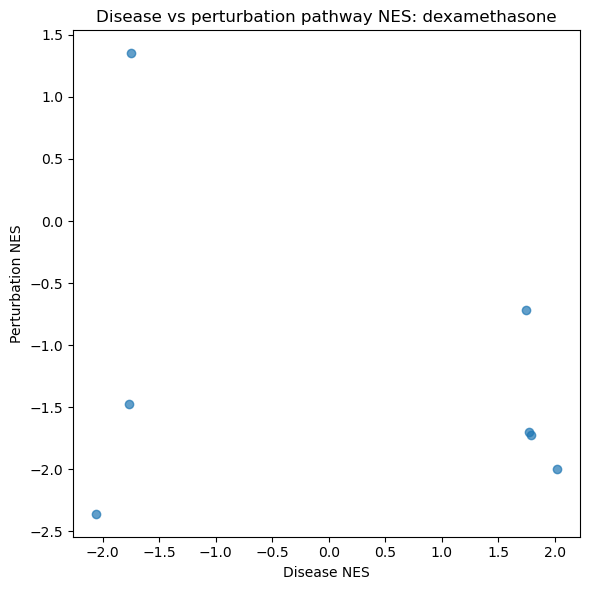

In [22]:
if aligned.shape[0] > 0:
    first_pert = aligned["perturbation_name"].iloc[0]
    preview_df = aligned[aligned["perturbation_name"] == first_pert].copy()

    plt.figure(figsize=(6, 6))
    plt.scatter(preview_df["disease_NES"], preview_df["NES"], alpha=0.7)
    plt.xlabel("Disease NES")
    plt.ylabel("Perturbation NES")
    plt.title(f"Disease vs perturbation pathway NES: {first_pert}")
    plt.tight_layout()
    plt.savefig(
        RESULTS_FIGURES / "lincs_preview_disease_vs_first_perturbation_scatter.png",
        dpi=300
    )
    plt.show()
else:
    print("No aligned pathways found yet.")


## 15. Preview candidate reversing perturbations


In [23]:
preview_scores = []

for perturbation_name, sub in aligned.groupby("perturbation_name"):
    sub = sub.dropna(subset=["disease_NES", "NES"]).copy()
    if sub.shape[0] >= 1:
        corr = sub["disease_NES"].corr(sub["NES"], method="pearson")
        preview_scores.append({
            "perturbation_name": perturbation_name,
            "n_shared_pathways": sub.shape[0],
            "pearson_corr": corr
        })

preview_scores_df = pd.DataFrame(preview_scores).sort_values("pearson_corr", ascending=True)
preview_scores_df


,perturbation_name,n_shared_pathways,pearson_corr
0,budesonide,5,-0.504352
1,dexamethasone,7,-0.278907
3,tofacitinib,6,0.477599
2,ruxolitinib,4,0.593478


In [24]:
preview_scores_df.to_csv(
    RESULTS_TABLES / "lincs_preview_perturbation_reversal_scores.tsv",
    sep="\t",
    index=False
)

print("Saved:", RESULTS_TABLES / "lincs_preview_perturbation_reversal_scores.tsv")


Saved: ../results/tables/lincs_preview_perturbation_reversal_scores.tsv


## 16. How to interpret skips

If a perturbation is skipped, it usually means:

- the perturbation signature is too small
- too few genes overlap with the chosen pathway library
- `min_size=15` is too strict for that signature

For a strong final project, expand each perturbation to around:

- 50 up genes
- 50 down genes

so that each perturbation has roughly 100 ranked genes.


## 17. Recommended next step

Once this notebook runs successfully, move to:

- `04_anticorrelation.ipynb`

That notebook will:
- compute formal disease–perturbation anticorrelation
- rank the strongest reversing perturbations
- identify the most promising candidate compounds and targets
